# 🔁 **Recurrent Neural Networks (RNN)**

Tekrarlayan Sinir Ağları (RNN), klasik ileri beslemeli (feedforward) ağlardan farklı olarak, geçmiş bilgiyi saklayabilen ve bu bilgiyi sonraki adımlarda kullanabilen yapılardır.

RNN’in temel mantığı:

Bir zaman adımında üretilen çıktı (özellikle gizli katman çıktıları),
Bir sonraki zaman adımında girdi olarak tekrar kullanılır.

Bu sayede model:
➡️ Geçmiş bilgiyi hatırlayabilir
➡️ Sıralı bağımlılıkları öğrenebilir

📌 Basit bir bakış açısıyla:

**Normal bir ağ:**

```
Girdi → Çıktı
```

**RNN:**

```
Girdi + Geçmiş Bilgi → Çıktı
```

Örneğin:

Bir gizli katmanda 10 giriş ve 128 gizli nöron varsa,
Bir sonraki adımda bu katman aslında 10 + 128 = 138 giriş alır.

İlk zaman adımında ise geçmiş bilgi olmadığı için bu değerler genellikle 0 ile başlatılır.



**⚠️ Vanishing Gradient Problemi**

Bu problem:

Geri yayılım (backpropagation) sırasında,
Gradyanların katmanlar boyunca çok küçük değerlere dönüşmesi sonucu ortaya çıkar.

Sonuç olarak:

Ağın erken katmanları neredeyse hiç öğrenemez
Uzun vadeli bağımlılıklar yakalanamaz

📉 Özellikle:

Sigmoid ve tanh gibi aktivasyon fonksiyonları
Zincir kuralı (chain rule) ile birlikte
Gradyanın üstel olarak küçülmesine neden olur

👉 Bu yüzden klasik RNN’ler:

Kısa süreli bağımlılıkları öğrenebilir (3–4 adım)
Ancak uzun vadeli bağımlılıkları öğrenmede başarısızdır

# 🧠 **Long Short-Term Memory (LSTM)**

LSTM, RNN’in geliştirilmiş bir versiyonudur ve:

Uzun vadeli bağımlılıkları öğrenebilir
Vanishing gradient problemini büyük ölçüde azaltır
🔹 LSTM Hücresinin Yapısı

Bir LSTM hücresi şu bileşenlerden oluşur:

🧠 Hafıza Hücresi (Cell State - C)

🚪 Forget Gate (Unutma Kapısı)

🚪 Input Gate (Giriş Kapısı)

🚪 Output Gate (Çıkış Kapısı)

Bu kapılar:

➡️ Bilginin ne kadarının tutulacağına

➡️ Ne kadarının unutulacağına

➡️ Ne kadarının dışarı aktarılacağına

karar verir.

# 🚀 Uygulama

Bu notebook’ta:

**👉 LSTM kullanarak IBM hisse senedi fiyatlarını (2017) tahmin edeceğiz.**

# Gerekli Kütüphanelerin Yüklenmesi

Bu bölümde, veri işleme, model oluşturma ve değerlendirme için gerekli kütüphaneler içe aktarılmaktadır:

*   NumPy: Sayısal işlemler için
*   Matplotlib: Grafik çizimi için
*   Pandas: Veri okuma ve düzenleme için
*   MinMaxScaler: Veriyi ölçeklemek için
*   Keras (Sequential, LSTM, GRU, Dense, Dropout, Bidirectional: Derin öğrenme modeli oluşturmak için
*   SGD: Optimizasyon algoritması
*   mean_squared_error: Model performansını ölçmek için







In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error


# Tahmin Sonuçlarının Görselleştirilmesi ve Hata Hesabı

*   **plot_predictions():** Gerçek ve tahmin edilen değerleri grafik üzerinde karşılaştırmak için kullanılır.
*   **return_rmse():** Modelin tahmin hatasını RMSE (Root Mean Squared Error) metriği ile hesaplar.


📌 RMSE değeri ne kadar düşükse, model o kadar başarılıdır.

In [2]:
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Veri Setinin Yüklenmesi

Bu adımda IBM hisse senedi verisi CSV dosyasından okunmaktadır.

*   index_col='Date': Tarih sütunu indeks olarak ayarlanır
*   parse_dates=['Date']: Tarih verileri uygun formatta işlenir
*   dataset.head(): Veri setinin ilk 5 satırı görüntülenir






In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Google Drive üzerindeki dosya yolu
# Lütfen 'IBM_stock_data.csv' kısmını gerçek dosya adınızla güncelleyin.
file_path = '/content/drive/MyDrive/2025-2026 Bahar Dönemi/Doğal Dil İşleme/Uygulamalar/6. Hafta RNN_LSTM_GRU/archive/IBM_2006-01-01_to_2018-01-01.csv'

# CSV dosyasını oku
dataset = pd.read_csv(file_path, index_col='Date', parse_dates=['Date'])

# Veri setinin ilk 5 satırını görüntüle
display(dataset.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


# Eğitim ve Test Verisinin Ayrılması

Veri seti, modelin eğitilmesi ve test edilmesi için ikiye ayrılmıştır:

training_set: 2016 yılına kadar olan veriler (eğitim verisi)

test_set: 2017 yılına ait veriler (test verisi)

📌 iloc[:,1:2] ifadesi, yalnızca ilgili fiyat sütununun (örneğin "Open") seçilmesini sağlar.

In [7]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

# Verinin Görselleştirilmesi

Bu adımda “High” (en yüksek fiyat) sütunu seçilerek eğitim ve test verileri grafik üzerinde gösterilmektedir.

2016 öncesi veriler → Eğitim seti
2017 ve sonrası veriler → Test seti

📌 Bu görselleştirme, modelin öğreneceği veri dağılımını ve zaman içindeki değişimi anlamak için kullanılır.

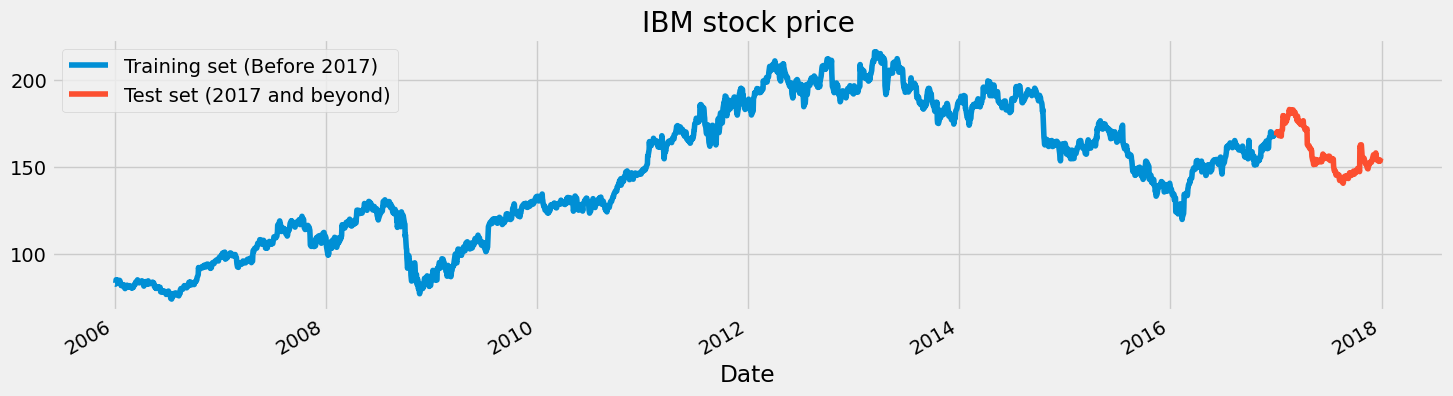

In [8]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

**Verinin Ölçeklenmesi (Normalization)**

Bu adımda eğitim verisi 0–1 aralığına ölçeklenmektedir.

MinMaxScaler kullanılarak veriler normalize edilir

Modelin daha hızlı ve stabil öğrenmesi sağlanır

📌 Sinir ağları, özellikle LSTM/GRU, ölçeklenmiş verilerle daha iyi performans gösterir.

In [9]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)


**Zaman Adımlı Veri Yapısının Oluşturulması**

LSTM modelleri geçmiş bilgiyi kullanarak tahmin yaptığı için veri, zaman adımları (timesteps) şeklinde hazırlanır.

Her örnek için son 60 günün verisi giriş (X) olarak kullanılır
Bir sonraki günün değeri ise hedef (y) olarak belirlenir

📌 Yani model:

➡️ Son 60 günü görerek

➡️ 61. günü tahmin etmeyi öğrenir

Son olarak:

X_train → Girdi verisi (60 zaman adımı)

y_train → Hedef değer

In [10]:
X_train = []
y_train = []
for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

**Verinin Yeniden Şekillendirilmesi (Reshaping)**

LSTM katmanları, girdinin 3 boyutlu olmasını bekler:

***`(samples,timesteps,features)`***

Bu adımda veri bu formata dönüştürülür.

samples → Örnek sayısı

timesteps → 60 (geçmiş adım sayısı)

features → 1 (tek özellik: fiyat)

📌 Bu dönüşüm, verinin LSTM modeline uygun hale getirilmesini sağlar.

In [11]:
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# LSTM Modelinin Oluşturulması ve Eğitilmesi

Bu adımda çok katmanlı bir LSTM modeli oluşturulmuş ve eğitilmiştir.

Model, 4 adet LSTM katmanı içermektedir.

Her katmandan sonra Dropout (0.2) uygulanarak aşırı öğrenme (overfitting) azaltılır.

Son katman Dense (1 nöron) olup tahmin değerini üretir.

**📌 return_sequences=True:**

Ara katmanlarda kullanılır
Çıktının bir sonraki LSTM katmanına aktarılmasını sağlar

**Model Eğitimi**

optimizer: rmsprop

loss: mean_squared_error

epochs: 50

batch_size: 32

📌 Model, eğitim verisi üzerinden öğrenerek gelecekteki değerleri tahmin edebilir hale gelir.

In [12]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=50,batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - loss: 0.0221
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0101
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 0.0078
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - loss: 0.0074
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - loss: 0.0058
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - loss: 0.0062
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0050
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0048
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - loss: 0.0046
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0040
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - loss: 0.0038
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0035
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0033
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms

**Test Verisinin Hazırlanması**

Test verisi de eğitim verisindeki gibi 60 zaman adımlı girişler oluşturulacak şekilde hazırlanır.

Bunun için “High” sütununun tamamı birleştirilir
Test kümesindeki ilk tahmin için gerekli olan önceki 60 değer de alınır
Daha sonra veriler eğitimde kullanılan ölçekleyici (sc) ile normalize edilir

📌 Böylece test verisi, modelin beklediği giriş yapısına uygun hale getirilir.

In [13]:
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

**Test Verisi ile Tahmin Yapılması**

Bu adımda test verisi kullanılarak modelden tahmin alınır.

Test verisi için yine 60 zaman adımlı girişler oluşturulur

Veri, LSTM’e uygun olacak şekilde yeniden boyutlandırılır

Eğitilen model ile tahminler üretilir

Son olarak tahminler, normalize edilmiş halden çıkarılarak gerçek fiyat ölçeğine geri dönüştürülür

📌 Böylece modelin ürettiği sonuçlar, gerçek hisse senedi fiyatları ile karşılaştırılabilir hale gelir.

In [14]:
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step


**Tahmin Sonuçlarının Görselleştirilmesi**

Bu adımda:

Gerçek fiyatlar (test_set)
Modelin tahmin ettiği fiyatlar (predicted_stock_price)

aynı grafik üzerinde karşılaştırılır.

📌 Bu görselleştirme, modelin performansını görsel olarak değerlendirmeyi sağlar.

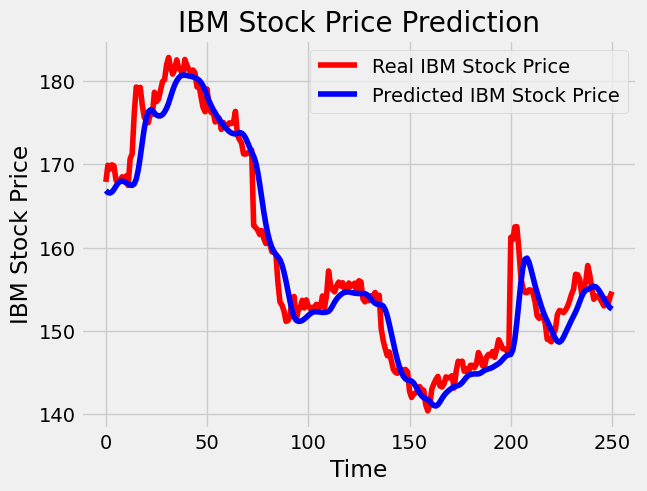

In [15]:
plot_predictions(test_set,predicted_stock_price)

**Model Performansının Değerlendirilmesi**

Bu adımda modelin tahmin başarısı RMSE (Root Mean Squared Error) metriği ile ölçülür.

📌 RMSE:

Gerçek değerler ile tahminler arasındaki farkı hesaplar
Değer ne kadar küçükse, model o kadar başarılıdır

In [16]:
return_rmse(test_set,predicted_stock_price)

The root mean squared error is 3.0370529457770523.


# **GRU (Gated Recurrent Unit)**

LSTM, sıralı veriler için güçlü bir model olsa da tek seçenek değildir. Bir diğer yaygın mimari:

**👉 GRU (Gated Recurrent Unit)**

**📌 GRU ve LSTM:**

Benzer performanslar gösterir
Hangisinin daha iyi olduğu problem ve veri setine bağlıdır
GRU genellikle daha hızlı ve daha kolay eğitilir

**GRU’nun Temel Özellikleri**

LSTM’deki gibi ayrı bir memory (cell state) yapısı yoktur

Tüm bilgi doğrudan hidden state üzerinden taşınır

Daha az parametreye sahiptir

📌 Bu nedenle:

Daha az veri ile öğrenebilir
Eğitim süresi daha kısadır

**GRU Kapıları**

GRU, LSTM’den farklı olarak 2 kapı içerir:

🔄 Reset Gate: Yeni bilginin geçmiş bilgi ile nasıl birleşeceğini belirler

🔁 Update Gate: Geçmiş bilginin ne kadarının korunacağını belirler

📌 Update gate: LSTM’deki input gate + forget gate görevini üstlenir

# GRU Modelinin Oluşturulması ve Eğitilmesi

Bu adımda çok katmanlı bir GRU modeli kurulmuş ve eğitim verisi ile eğitilmiştir.

Model, 4 adet GRU katmanı içermektedir

Her katmandan sonra Dropout (0.2) uygulanarak aşırı öğrenme azaltılır

Son katmanda Dense (1 nöron) kullanılarak tahmin değeri üretilir

📌 Ara katmanlarda kullanılan return_sequences=True ifadesi, çıktıların sonraki GRU katmanına aktarılmasını sağlar.

**Model Eğitimi**

optimizer: SGD

loss: mean_squared_error

epochs: 50

batch_size: 150

📌 Bu yapı ile GRU modelinin zaman serisi verisi üzerindeki tahmin performansı gözlemlenebilir.

In [18]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))
# Compiling the RNN
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, decay=1e-7, momentum=0.9, nesterov=False),loss='mean_squared_error')
# Fitting to the training set
regressorGRU.fit(X_train,y_train,epochs=50,batch_size=150)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - loss: 0.1302
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 464ms/step - loss: 0.0503
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step - loss: 0.0200
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 400ms/step - loss: 0.0055
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - loss: 0.0044
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - loss: 0.0041
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - loss: 0.0038
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - loss: 0.0036
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - loss: 0.0034
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - loss: 0.0035
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - loss: 0.0034
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/step - loss: 0.0033
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 402ms/step - loss: 0.0031
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - loss: 0.0031
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 361ms/step - loss: 0.

**GRU Modeli ile Tahmin Yapılması**

Bu adımda test verisi kullanılarak GRU modeli üzerinden tahminler üretilir.

Test verisi için 60 zaman adımlı girişler oluşturulur

Veri, GRU modelinin beklediği 3 boyutlu yapıya dönüştürülür

Eğitilmiş model ile tahminler alınır

Son olarak tahminler, ölçeklenmiş formdan çıkarılarak gerçek fiyat değerlerine geri çevrilir

📌 Böylece GRU modelinin ürettiği tahminler, gerçek verilerle karşılaştırmaya hazır hale gelir.

In [19]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step


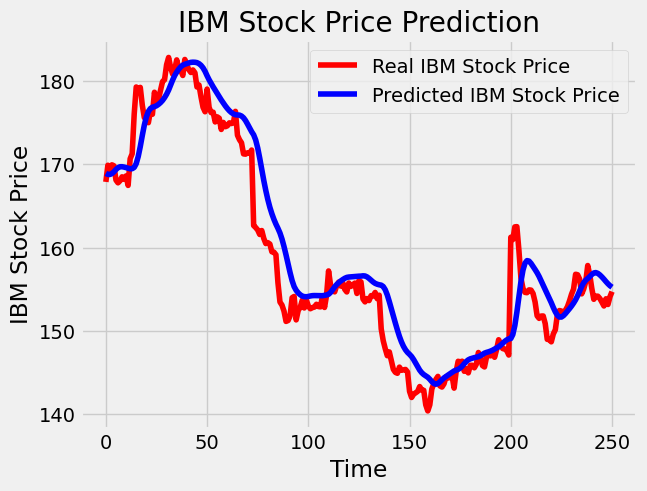

In [20]:
# Visualizing the results for GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [21]:
# Evaluating GRU
return_rmse(test_set,GRU_predicted_stock_price)

The root mean squared error is 3.569972077091583.


# Kaynak

Bu notebook, aşağıdaki Kaggle çalışmasından faydalanılarak hazırlanmıştır:

🔗 https://www.kaggle.com/code/thebrownviking20/intro-to-recurrent-neural-networks-lstm-gru